In [1]:
import pandas as pd
from sqlalchemy import create_engine

# Simulazione campionamenti idrogeologici
data_idro = {
    'bacino_id': ['Nord', 'Nord', 'Sud', 'Nord', 'Sud', 'Est', 'Nord'],
    'tecnico_id': ['T_Rossi', 'T_Bianchi', 'T_Verdi', 'T_Rossi', 'T_Neri', 'T_Gialli', 'T_Bianchi'],
    'tipo_prelievo': ['Condiviso', 'Condiviso', 'Condiviso', 'Privato', 'Condiviso', 'Condiviso', 'Condiviso'],
    'giorno_settimana': ['Lunedì', 'Lunedì', 'Martedì', 'Lunedì', 'Mercoledì', 'Venerdì', 'Lunedì'],
    'ora_inizio_prelievo': [8, 8, 14, 9, 10, 18, 8],
    'durata_spurgo_h': [12.5, 5.0, 11.2, 2.0, 15.0, 8.5, 10.1] # Ore necessarie per spurgare il pozzo
}

engine = create_engine('sqlite://')
pd.DataFrame(data_idro).to_sql('monitoraggio_pozzi', engine, index=False)

print("Database Geologico pronto: tabella 'monitoraggio_pozzi' caricata.")

# Mostra la tabella 
df_campionamenti = pd.DataFrame(data_idro)

# Creiamo il motore SQL in memoria (senza password!)
engine = create_engine('sqlite://')
df_campionamenti.to_sql('monitoraggio_pozzi', engine, index=False)
df_campionamenti.head(10)

Database Geologico pronto: tabella 'monitoraggio_pozzi' caricata.


,bacino_id,tecnico_id,tipo_prelievo,giorno_settimana,ora_inizio_prelievo,durata_spurgo_h
0,Nord,T_Rossi,Condiviso,Lunedì,8,12.5
1,Nord,T_Bianchi,Condiviso,Lunedì,8,5.0
2,Sud,T_Verdi,Condiviso,Martedì,14,11.2
3,Nord,T_Rossi,Privato,Lunedì,9,2.0
4,Sud,T_Neri,Condiviso,Mercoledì,10,15.0
5,Est,T_Gialli,Condiviso,Venerdì,18,8.5
6,Nord,T_Bianchi,Condiviso,Lunedì,8,10.1


In [2]:
#Rischieste:

#Query 1: Diversità dei Tecnici per Bacino
#Trova il numero di tecnici unici che hanno operato in ogni bacino per prelievi di tipo 'Condiviso'.
#Obiettivo: Valutare la rotazione del personale nei siti di monitoraggio.

#Query 2: Orari di Picco delle Attività
#Trova le 10 combinazioni più frequenti di giorno e ora in cui iniziano le operazioni di spurgo e prelievo.
#Obiettivo: Identificare i momenti di massimo carico per i laboratori che ricevono i campioni.

#Query 3: Pozzi a Lenta Rigenerazione
#Trova i tecnici la cui durata media di spurgo (necessaria per stabilizzare i parametri chimico-fisici) è superiore a 10 ore.
#Obiettivo: Identificare siti con bassa permeabilità o criticità tecniche che richiedono tempi lunghi.
#=========================================================================================================

#Query 1 (Diversità): Ricorda che il DISTINCT va all'interno del COUNT per ignorare le ripetizioni dello stesso tecnico nello stesso bacino.

#Query 2 (Orari di Picco): Dovrai raggruppare per due colonne contemporaneamente: giorno_settimana e ora_inizio_prelievo.

#uery 3 (Lenta Rigenerazione): È qui che userai il HAVING dopo il GROUP BY per filtrare la media superiore a 10 ore.

In [3]:
Q1 = """SELECT 
    bacino_id,
    COUNT(DISTINCT tecnico_id) AS tecnici_distinti
FROM monitoraggio_pozzi
WHERE tipo_prelievo = 'Condiviso'
GROUP BY bacino_id
ORDER BY tecnici_distinti DESC, bacino_id;
"""

Q2 = """SELECT 
    giorno_settimana,
    ora_inizio_prelievo,
    COUNT(*) AS numero_operazioni
FROM monitoraggio_pozzi
GROUP BY giorno_settimana, ora_inizio_prelievo
ORDER BY numero_operazioni DESC
LIMIT 10;
"""

Q3 = """SELECT 
    tecnico_id,
    AVG(durata_spurgo_h) AS durata_media_spurgo
FROM monitoraggio_pozzi
GROUP BY tecnico_id
HAVING AVG(durata_spurgo_h) > 10;  
"""

# Esecuzione 
R1 = pd.read_sql_query(Q1, engine)
print("Diversità dei Tecnici per Bacino:")
display(R1)

R2 = pd.read_sql_query(Q2, engine)
print("Orari di Picco delle Attività:")
display(R2)

R3 = pd.read_sql_query(Q3, engine)
print("Pozzi a Lenta Rigenerazione:")
display(R3)

Diversità dei Tecnici per Bacino:


,bacino_id,tecnici_distinti
0,Nord,2
1,Sud,2
2,Est,1


Orari di Picco delle Attività:


,giorno_settimana,ora_inizio_prelievo,numero_operazioni
0,Lunedì,8,3
1,Lunedì,9,1
2,Martedì,14,1
3,Mercoledì,10,1
4,Venerdì,18,1


Pozzi a Lenta Rigenerazione:


,tecnico_id,durata_media_spurgo
0,T_Neri,15.0
1,T_Verdi,11.2


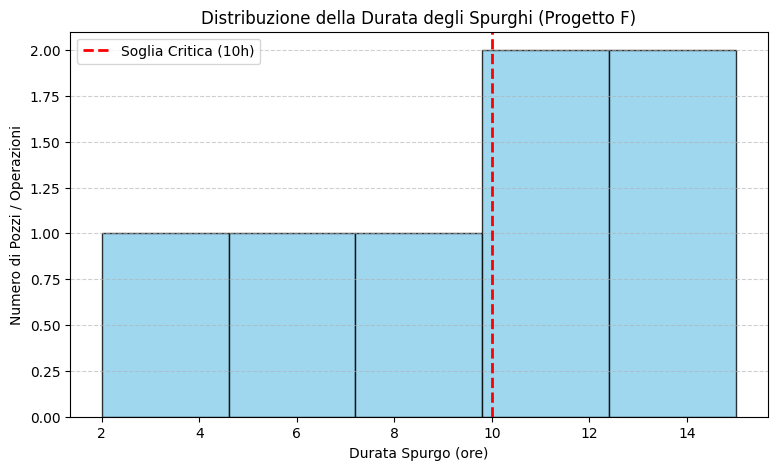

In [4]:
import matplotlib.pyplot as plt

# Recuperiamo i dati dalla colonna 'durata_spurgo_h'
# Se stai usando il DataFrame 'df_campionamenti' creato prima:
durate = df_campionamenti['durata_spurgo_h']

plt.figure(figsize=(9, 5))

# Creazione istogramma
plt.hist(durate, bins=5, color='skyblue', edgecolor='black', alpha=0.8)

# Aggiungiamo una linea rossa per evidenziare la soglia delle 10 ore
plt.axvline(10, color='red', linestyle='dashed', linewidth=2, label='Soglia Critica (10h)')

# Personalizzazione
plt.title('Distribuzione della Durata degli Spurghi (Progetto F)')
plt.xlabel('Durata Spurgo (ore)')
plt.ylabel('Numero di Pozzi / Operazioni')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

Cosa ci dice questo grafico?
La Soglia: La linea rossa tratteggiata separa chiaramente i campionamenti "standard" da quelli "critici".

Frequenza: Noterai che una buona parte delle operazioni cade a destra della linea rossa (12.5, 11.2, 15.0, 10.1 ore). Questo suggerisce che il problema della bassa permeabilità o della rigenerazione lenta non è un caso isolato, ma una caratteristica diffusa nell'area di studio.

Pianificazione: Per un geologo senior, questo grafico giustifica la richiesta di più budget o di attrezzature più potenti (pompe ad alta portata) per velocizzare le operazioni future.